In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [49]:
np.random.seed(42)

n = 200

df = pd.DataFrame({
    "CGPA": np.round(np.random.uniform(5.5, 9.8, n), 2),
    "AptitudeScore": np.random.randint(40, 100, n),
    "CommunicationScore": np.random.randint(40, 100, n),
    "Internships": np.random.randint(0, 4, n),
    "Projects": np.random.randint(0, 6, n),
    "Department": np.random.choice(
        ["CSE", "IT", "ECE", "EEE"],
        n
    ),
    "Gender": np.random.choice(
        ["Male", "Female"],
        n
    )
})

df.head()

,CGPA,AptitudeScore,CommunicationScore,Internships,Projects,Department,Gender
0,7.11,63,97,0,2,CSE,Male
1,9.59,91,94,2,4,IT,Male
2,8.65,50,65,3,1,ECE,Male
3,8.07,88,76,0,0,EEE,Female
4,6.17,47,65,2,5,ECE,Female


In [50]:
df["PlacementScore"] = (
    df["CGPA"] * 10
    + df["AptitudeScore"] * 0.5
    + df["CommunicationScore"] * 0.3
    + df["Internships"] * 5
    + df["Projects"] * 2
)

In [51]:
df["PlacementStatus"] = np.where(
    df["PlacementScore"] >= 100,
    "Placed",
    "Not Placed"
)

In [52]:
print(df.head())

print("\nPlacement Status:")
print(df["PlacementStatus"].value_counts())

   CGPA  AptitudeScore  CommunicationScore  Internships  Projects Department  \
0  7.11             63                  97            0         2        CSE   
1  9.59             91                  94            2         4         IT   
2  8.65             50                  65            3         1        ECE   
3  8.07             88                  76            0         0        EEE   
4  6.17             47                  65            2         5        ECE   

   Gender  PlacementScore PlacementStatus  
0    Male           135.7          Placed  
1    Male           187.6          Placed  
2    Male           148.0          Placed  
3  Female           147.5          Placed  
4  Female           124.7          Placed  

Placement Status:
PlacementStatus
Placed    200
Name: count, dtype: int64


In [53]:
feature_cols = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects",
    "Department",
    "Gender"
]

X = df[feature_cols]

y = df["PlacementStatus"]

In [54]:
numeric_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

categorical_features = [
    "Department",
    "Gender"
]

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [56]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 160
Validation samples: 40


In [57]:
dt_gini = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=42
            )
        )
    ]
)

In [58]:
dt_gini.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [59]:
gini_train_pred = dt_gini.predict(X_train)
gini_val_pred = dt_gini.predict(X_val)

In [60]:
gini_train_acc = accuracy_score(
    y_train,
    gini_train_pred
)

gini_val_acc = accuracy_score(
    y_val,
    gini_val_pred
)

print("Gini Train Accuracy:", gini_train_acc)
print("Gini Validation Accuracy:", gini_val_acc)

Gini Train Accuracy: 1.0
Gini Validation Accuracy: 1.0


In [61]:
print("========== GINI CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        gini_val_pred,
        zero_division=0
    )
)

========== GINI CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Placed       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [62]:
dt_entropy = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="entropy",
                random_state=42
            )
        )
    ]
)

In [63]:
dt_entropy.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', random_state=42))])

In [64]:
entropy_train_pred = dt_entropy.predict(X_train)
entropy_val_pred = dt_entropy.predict(X_val)

In [65]:
entropy_train_acc = accuracy_score(
    y_train,
    entropy_train_pred
)

entropy_val_acc = accuracy_score(
    y_val,
    entropy_val_pred
)

print("Entropy Train Accuracy:", entropy_train_acc)
print("Entropy Validation Accuracy:", entropy_val_acc)

Entropy Train Accuracy: 1.0
Entropy Validation Accuracy: 1.0


In [66]:
comparison = pd.DataFrame({
    "Criterion": [
        "Gini",
        "Entropy"
    ],
    "Train Accuracy": [
        gini_train_acc,
        entropy_train_acc
    ],
    "Validation Accuracy": [
        gini_val_acc,
        entropy_val_acc
    ]
})

comparison

,Criterion,Train Accuracy,Validation Accuracy
0,Gini,1.0,1.0
1,Entropy,1.0,1.0


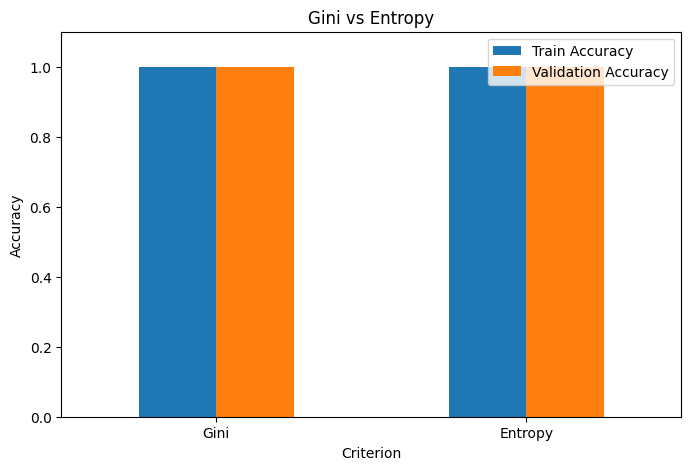

In [67]:
comparison.plot(
    x="Criterion",
    y=[
        "Train Accuracy",
        "Validation Accuracy"
    ],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Gini vs Entropy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

In [68]:
dt_visual = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [69]:
dt_visual.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=3, random_state=42))])

In [70]:
feature_names = (
    numeric_features
    + list(
        dt_visual
        .named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .get_feature_names_out(categorical_features)
    )
)

In [71]:
tree_model = dt_visual.named_steps["classifier"]

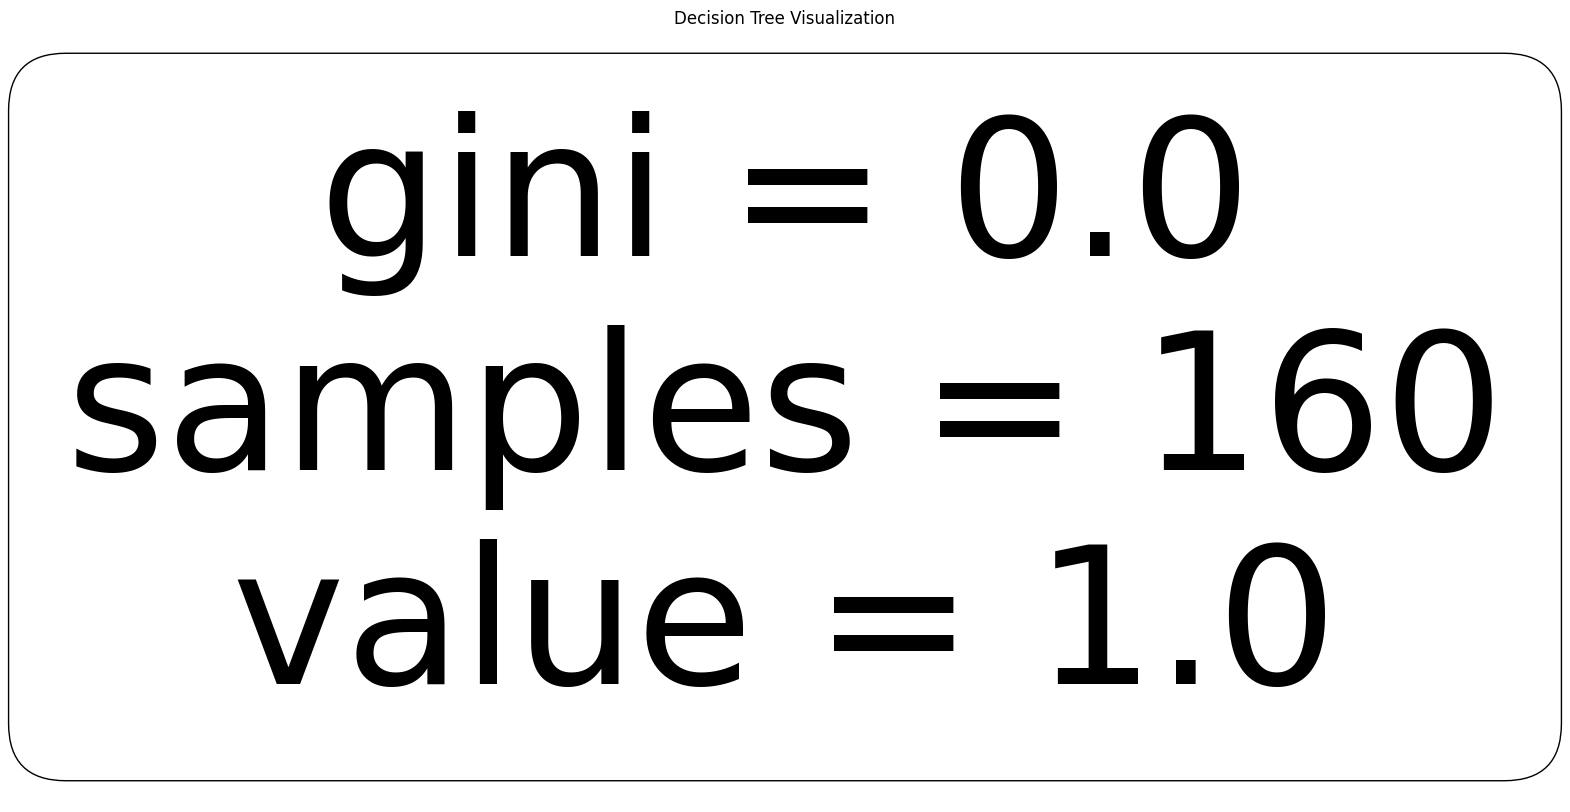

In [72]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


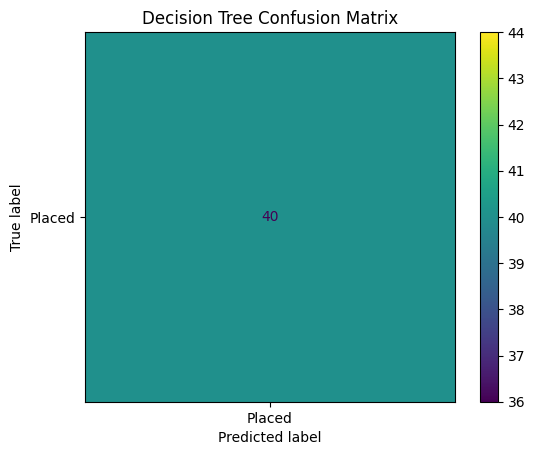

In [73]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    gini_val_pred
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [74]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

In [75]:
dt_full = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_full.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [76]:
path = dt_full.cost_complexity_pruning_path(
    X_train_processed,
    y_train
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

In [77]:
print("CCP Alpha Values:")
print(ccp_alphas)

CCP Alpha Values:
[0.]


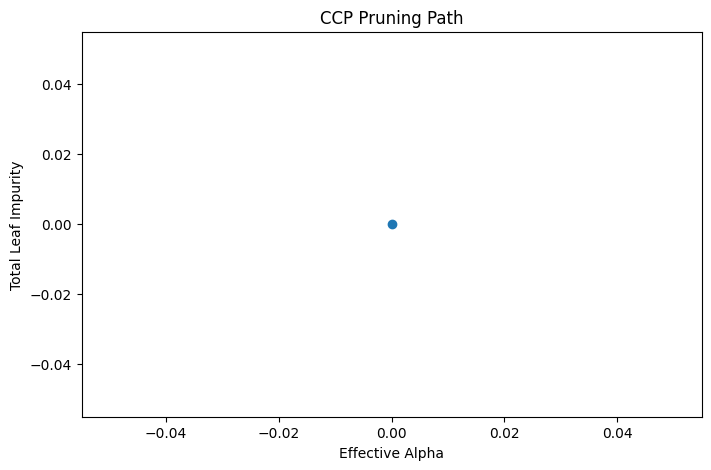

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    ccp_alphas,
    impurities,
    marker="o"
)

plt.xlabel("Effective Alpha")
plt.ylabel("Total Leaf Impurity")
plt.title("CCP Pruning Path")

plt.show()

In [32]:
pruning_results = []

for alpha in ccp_alphas:

    clf = DecisionTreeClassifier(
        criterion="gini",
        ccp_alpha=alpha,
        random_state=42
    )

    clf.fit(
        X_train_processed,
        y_train
    )

    train_pred = clf.predict(X_train_processed)
    val_pred = clf.predict(X_val_processed)

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    pruning_results.append({
        "ccp_alpha": alpha,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "n_leaves": clf.get_n_leaves()
    })

pruning_df = pd.DataFrame(pruning_results)

pruning_df

,ccp_alpha,train_acc,val_acc,n_leaves
0,0.0,1.0,1.0,1


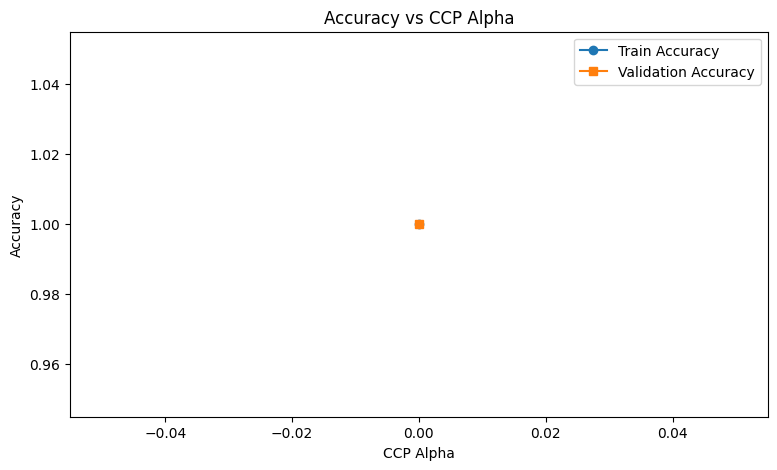

In [33]:
plt.figure(figsize=(9, 5))

plt.plot(
    pruning_df["ccp_alpha"],
    pruning_df["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    pruning_df["ccp_alpha"],
    pruning_df["val_acc"],
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("CCP Alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs CCP Alpha")
plt.legend()
plt.show()

In [34]:
def dt_report(
    X_train,
    y_train,
    X_val,
    y_val
):

    results = []

    for depth in range(1, 16):

        model = Pipeline(
            steps=[
                (
                    "preprocessor",
                    preprocessor
                ),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        criterion="gini",
                        max_depth=depth,
                        random_state=42
                    )
                )
            ]
        )

        model.fit(
            X_train,
            y_train
        )

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_acc = accuracy_score(
            y_train,
            train_pred
        )

        val_acc = accuracy_score(
            y_val,
            val_pred
        )

        tree = model.named_steps["classifier"]

        n_leaves = tree.get_n_leaves()

        results.append({
            "depth": depth,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "n_leaves": n_leaves
        })

    results_df = pd.DataFrame(results)

    # Plot accuracy curves
    plt.figure(figsize=(9, 5))

    plt.plot(
        results_df["depth"],
        results_df["train_acc"],
        marker="o",
        label="Train Accuracy"
    )

    plt.plot(
        results_df["depth"],
        results_df["val_acc"],
        marker="s",
        label="Validation Accuracy"
    )

    plt.xlabel("Maximum Depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Accuracy vs Maximum Depth")
    plt.legend()
    plt.grid(True)

    plt.show()

    # Plot number of leaves
    plt.figure(figsize=(9, 5))

    plt.plot(
        results_df["depth"],
        results_df["n_leaves"],
        marker="o"
    )

    plt.xlabel("Maximum Depth")
    plt.ylabel("Number of Leaves")
    plt.title("Number of Leaves vs Maximum Depth")

    plt.grid(True)

    plt.show()

    # Find best validation result
    best_row = results_df.loc[
        results_df["val_acc"].idxmax()
    ]

    print("========== BEST DECISION TREE ==========")
    print(best_row)

    return results_df

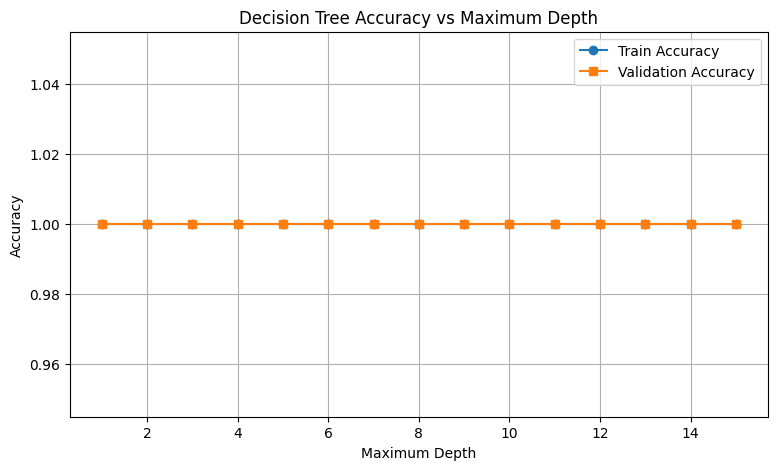

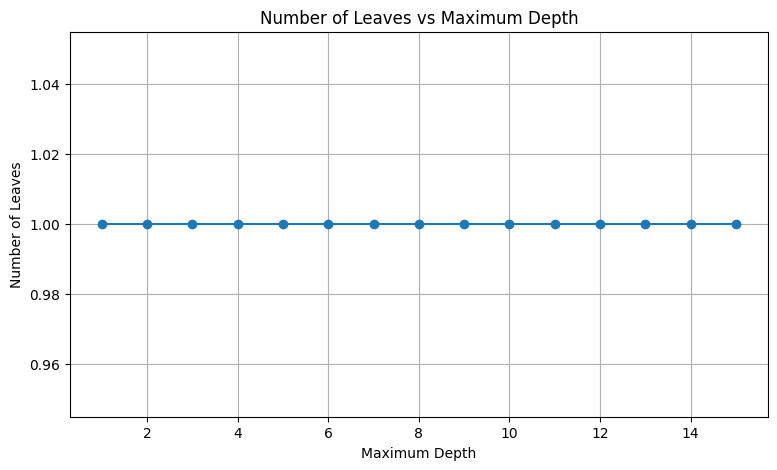

========== BEST DECISION TREE ==========
depth        1.0
train_acc    1.0
val_acc      1.0
n_leaves     1.0
Name: 0, dtype: float64


In [35]:
dt_results = dt_report(
    X_train,
    y_train,
    X_val,
    y_val
)

In [36]:
dt_results

,depth,train_acc,val_acc,n_leaves
0,1,1.0,1.0,1
1,2,1.0,1.0,1
2,3,1.0,1.0,1
3,4,1.0,1.0,1
4,5,1.0,1.0,1
5,6,1.0,1.0,1
6,7,1.0,1.0,1
7,8,1.0,1.0,1
8,9,1.0,1.0,1
9,10,1.0,1.0,1


In [37]:
best_depth = int(
    dt_results.loc[
        dt_results["val_acc"].idxmax(),
        "depth"
    ]
)

print("Best Depth:", best_depth)

Best Depth: 1


In [38]:
final_dt = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=best_depth,
                random_state=42
            )
        )
    ]
)

In [39]:
final_dt.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['CGPA', 'AptitudeScore',
                                                   'CommunicationScore',
                                                   'Internships', 'Projects']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Department', 'Gender'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=1, random_state=42))])

In [40]:
final_train_pred = final_dt.predict(X_train)
final_val_pred = final_dt.predict(X_val)

In [41]:
final_train_acc = accuracy_score(
    y_train,
    final_train_pred
)

final_val_acc = accuracy_score(
    y_val,
    final_val_pred
)

print("Final Train Accuracy:", final_train_acc)
print("Final Validation Accuracy:", final_val_acc)

Final Train Accuracy: 1.0
Final Validation Accuracy: 1.0


In [42]:
print("========== FINAL DECISION TREE REPORT ==========")

print(
    classification_report(
        y_val,
        final_val_pred,
        zero_division=0
    )
)

========== FINAL DECISION TREE REPORT ==========
              precision    recall  f1-score   support

      Placed       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



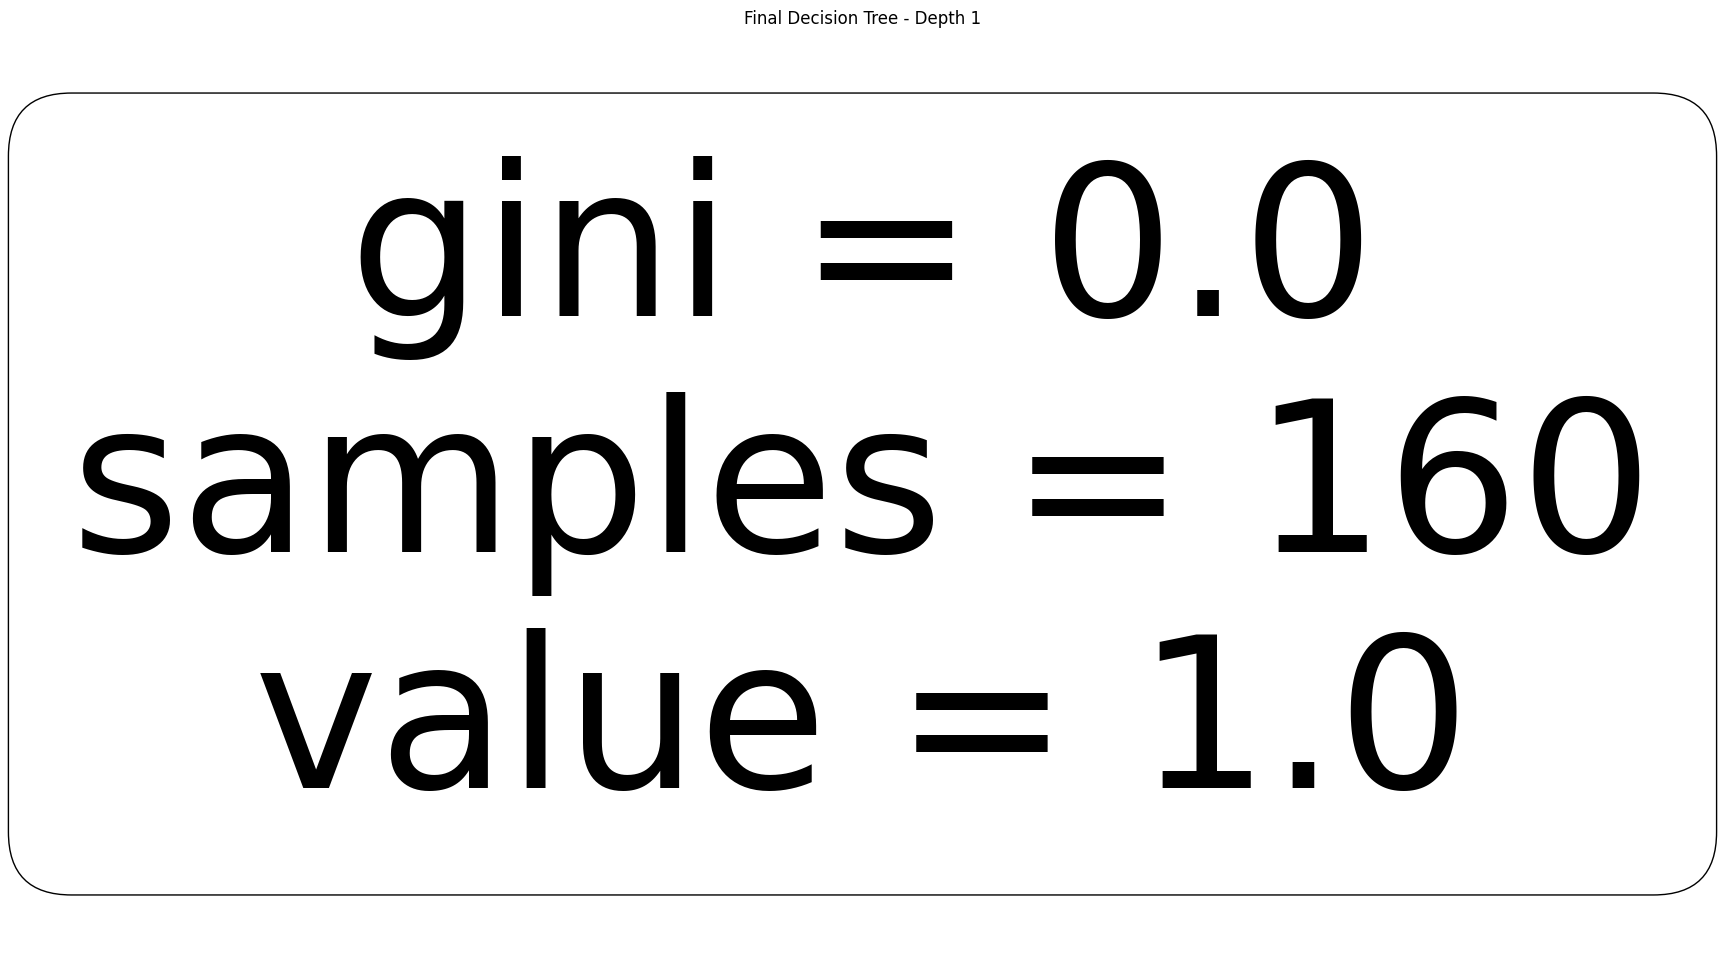

In [43]:
final_tree = final_dt.named_steps["classifier"]

final_feature_names = (
    numeric_features
    + list(
        final_dt
        .named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .get_feature_names_out(
            categorical_features
        )
    )
)

plt.figure(figsize=(22, 12))

plot_tree(
    final_tree,
    feature_names=final_feature_names,
    class_names=final_tree.classes_,
    filled=True,
    rounded=True
)

plt.title(
    f"Final Decision Tree - Depth {best_depth}"
)

plt.show()

In [44]:
print(
    "Number of Leaves:",
    final_tree.get_n_leaves()
)

print(
    "Tree Depth:",
    final_tree.get_depth()
)

Number of Leaves: 1
Tree Depth: 0


In [45]:
print("========================================")
print("GINI VS ENTROPY")
print("========================================")

print(
    "Gini Train Accuracy:",
    gini_train_acc
)

print(
    "Gini Validation Accuracy:",
    gini_val_acc
)

print(
    "Entropy Train Accuracy:",
    entropy_train_acc
)

print(
    "Entropy Validation Accuracy:",
    entropy_val_acc
)

GINI VS ENTROPY
Gini Train Accuracy: 1.0
Gini Validation Accuracy: 1.0
Entropy Train Accuracy: 1.0
Entropy Validation Accuracy: 1.0


In [46]:
criterion="gini"
criterion="entropy"

In [47]:
DecisionTreeClassifier(max_depth=1)

DecisionTreeClassifier(max_depth=1)